<a href="https://colab.research.google.com/github/arsingla786/MLFromScratch/blob/main/6Normalization_scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Normalization
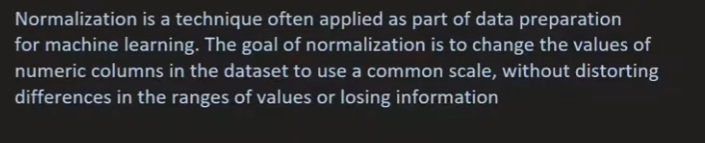

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tawfikelmetwally/wine-dataset")

print("Path to dataset files:", path)

100%|██████████| 4.45k/4.45k [00:00<00:00, 3.38MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/tawfikelmetwally/wine-dataset/versions/2


In [14]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/tawfikelmetwally/wine-dataset/versions/2/Wine dataset.csv',usecols=[0,1,2])

In [15]:
df.head()

,class,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


In [16]:
df.shape

(178, 3)

<Axes: xlabel='Alcohol', ylabel='Density'>

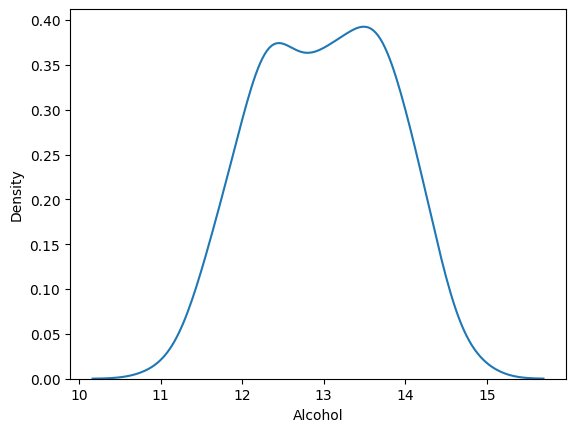

In [18]:
sns.kdeplot(df['Alcohol'])


<Axes: xlabel='Malic acid', ylabel='Density'>

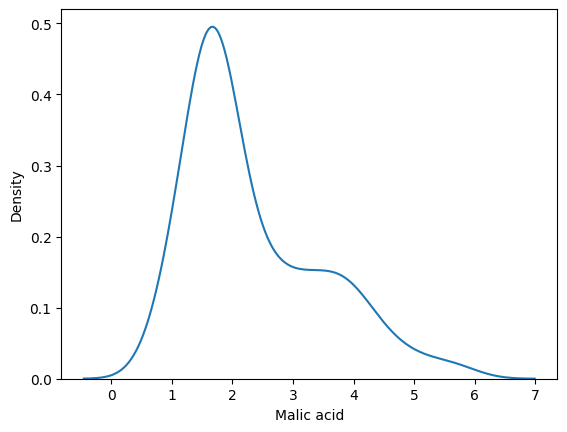

In [19]:
sns.kdeplot(df['Malic acid'])

In [20]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(df.drop('class',axis=1),
                                             df['class'],test_size=0.3,random_state=0)

In [21]:
xtrain.shape

(124, 2)

In [23]:
xtest.shape

(54, 2)

##**MinMax Scaling**

In [24]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
xtrain_scaled  = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

In [31]:
xtrain_scaled = pd.DataFrame(xtrain_scaled,columns=xtrain.columns)
xtest_scaled = pd.DataFrame(xtest_scaled,columns=xtest.columns)

In [32]:
np.round(xtrain_scaled.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


<Axes: xlabel='Alcohol', ylabel='Density'>

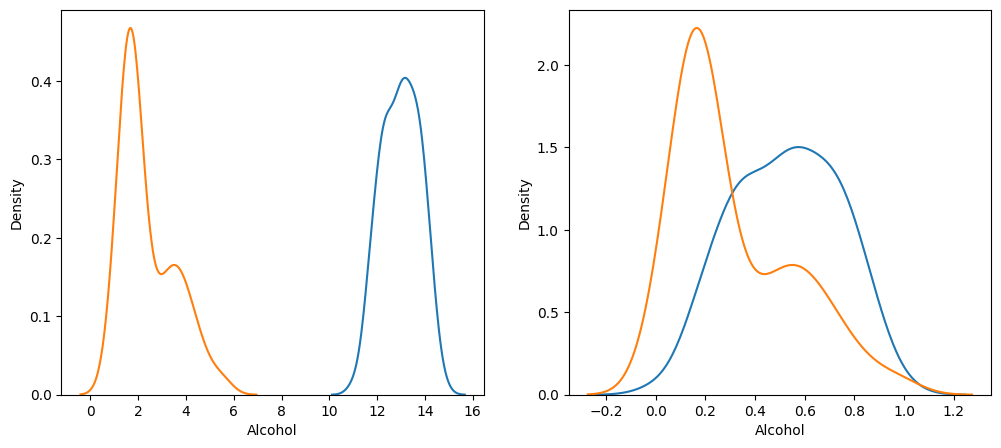

In [35]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
#before scaling
sns.kdeplot(xtrain['Alcohol'],ax=ax1)
sns.kdeplot(xtrain['Malic acid'],ax=ax1)
#after scaling
sns.kdeplot(xtrain_scaled['Alcohol'],ax=ax2)
sns.kdeplot(xtrain_scaled['Malic acid'],ax=ax2)

# **Robust Scaler . best with outliers**

In [39]:
from sklearn.preprocessing import RobustScaler
sc = RobustScaler()
xtrainscaled =  sc.fit_transform(xtrain)
xtestscaled = sc.transform(xtest)

In [43]:
xtrainscaled = pd.DataFrame(xtrainscaled,columns=xtrain.columns)
xtestscaled = pd.DataFrame(xtestscaled,columns=xtest.columns)

<Axes: xlabel='Alcohol', ylabel='Density'>

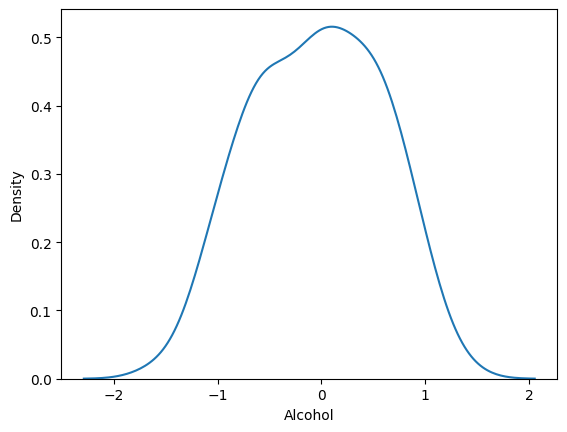

In [45]:

sns.kdeplot(xtrainscaled['Alcohol'])

In [46]:
np.round(xtrainscaled.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,-0.0,0.3
std,0.6,0.7
min,-1.6,-0.6
25%,-0.5,-0.2
50%,0.0,0.0
75%,0.5,0.8
max,1.3,2.3


<Axes: xlabel='Alcohol', ylabel='Density'>

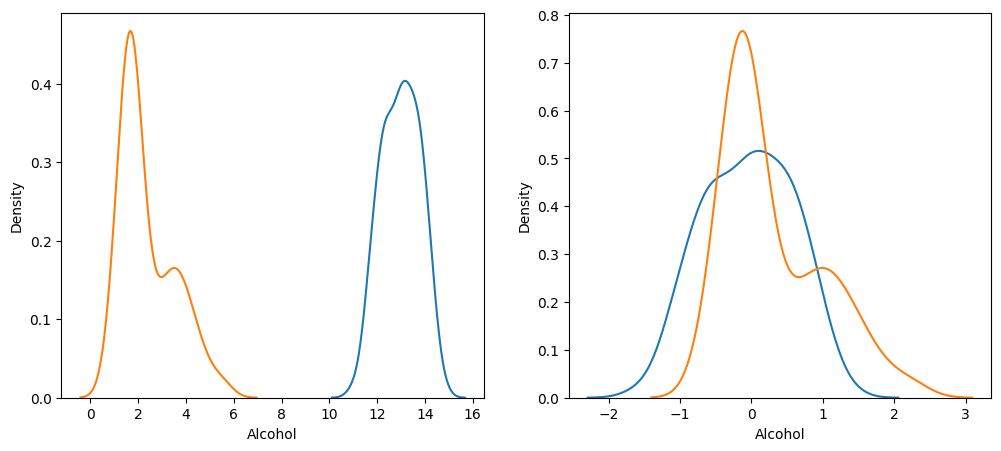

In [50]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
#before scaling
sns.kdeplot(xtrain['Alcohol'],ax=ax1)
sns.kdeplot(xtrain['Malic acid'],ax=ax1)

sns.kdeplot(xtrainscaled['Alcohol'],ax=ax2)
sns.kdeplot(xtrainscaled['Malic acid'],ax=ax2)